# 02 — Exploratory data analysis

Before building any model, we need to understand the game itself. Four questions drive this notebook, and each answer directly shapes a modeling decision later:

1. **How big is home advantage — and is it stable?** (If it isn't, our features need to capture that.)
2. **How much scoring is there, and does it drift over time?** (Form features are goal-based; we need a stable scale.)
3. **How good are the bookmakers?** (They're our benchmark — we should know how high the bar is *before* training anything.)
4. **Why is everyone convinced draws are hard to predict?** (Spoiler: the data makes this brutally clear.)

In [1]:
import sys
sys.path.append("..")

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import load_match_table, add_implied_probs

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {"H": "#1f77b4", "D": "#8c8c8c", "A": "#d62728"}
FIG_DIR = Path("../figures")

matches = add_implied_probs(load_match_table())
print(f"{len(matches)} matches, {matches['season'].nunique()} seasons")

4180 matches, 11 seasons


## 1. Home advantage — real, large, and not constant

Across all 11 seasons, home teams win ~44% of matches vs ~33% for away teams. But the season-by-season picture contains a natural experiment: the **2020-21 season was played almost entirely in empty stadiums** (COVID restrictions). If home advantage were purely about travel fatigue or pitch familiarity, empty stands shouldn't matter.

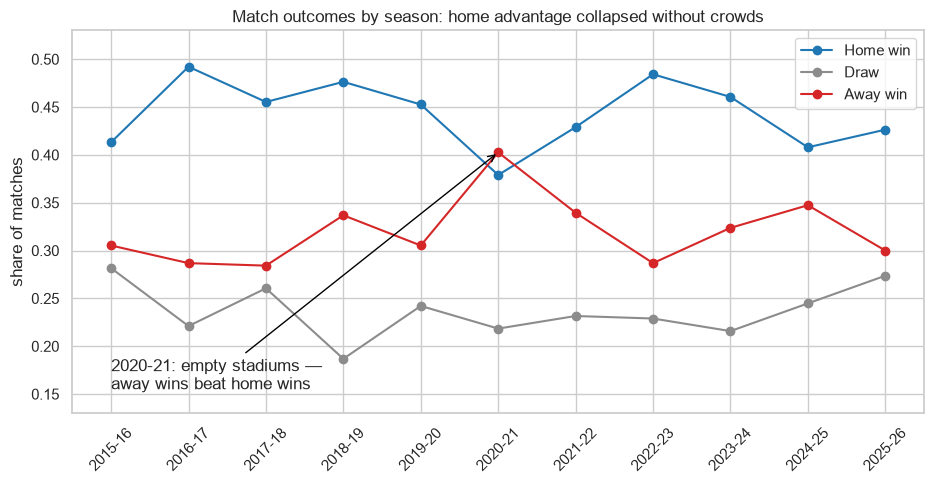

result,H,D,A
season,,,
2015-16,0.413,0.282,0.305
2016-17,0.492,0.221,0.287
2017-18,0.455,0.261,0.284
2018-19,0.476,0.187,0.337
2019-20,0.453,0.242,0.305
2020-21,0.379,0.218,0.403
2021-22,0.429,0.232,0.339
2022-23,0.484,0.229,0.287
2023-24,0.461,0.216,0.324


In [2]:
shares = (
    matches.groupby("season")["result"]
    .value_counts(normalize=True)
    .unstack()[["H", "D", "A"]]
)

fig, ax = plt.subplots(figsize=(9.5, 5))
for res, label in [("H", "Home win"), ("D", "Draw"), ("A", "Away win")]:
    ax.plot(shares.index, shares[res], marker="o", color=COLORS[res], label=label)

ax.annotate(
    "2020-21: empty stadiums —\naway wins beat home wins",
    xy=("2020-21", shares.loc["2020-21", "A"]),
    xytext=("2015-16", 0.155),
    arrowprops=dict(arrowstyle="->", color="black"),
)
ax.set_ylim(0.13, 0.53)
ax.set_ylabel("share of matches")
ax.set_title("Match outcomes by season: home advantage collapsed without crowds")
ax.legend(loc="upper right")
plt.xticks(rotation=45)
fig.tight_layout()
fig.savefig(FIG_DIR / "outcomes_by_season.png", dpi=150, bbox_inches="tight")
plt.show()

shares.round(3)

**Takeaway.** In 2020-21, home wins fell to 37.9% and away wins rose to 40.3% — the only season where playing at home was a *disadvantage*. Crowds appear to be a real component of home advantage. Since then home advantage has partially recovered but sits below the 2016-19 level (~41-43% vs ~46-49%).

**Modeling consequence:** "is home team" is a strong signal, but its strength drifts over time. This is one reason we'll use a *time-based* train/test split — a model must be judged on seasons it hasn't seen, under whatever conditions those seasons bring.

## 2. Scoring: stable, with one famous exception

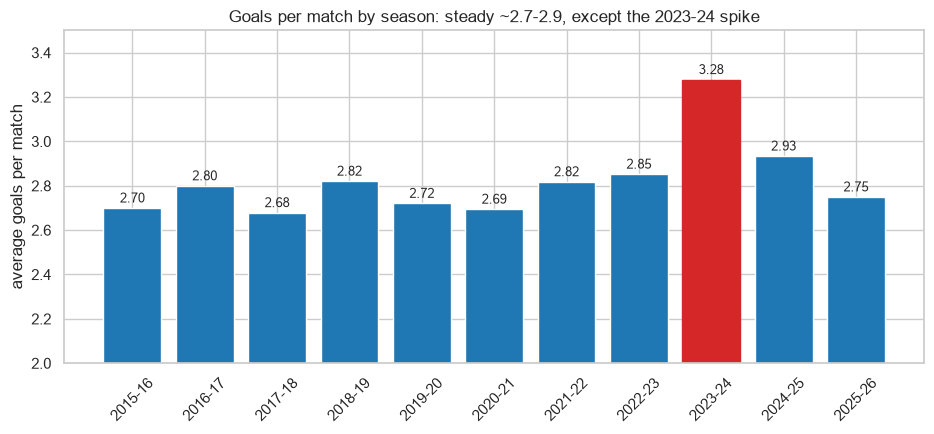

In [3]:
goals = (matches["home_goals"] + matches["away_goals"]).groupby(matches["season"]).mean()

fig, ax = plt.subplots(figsize=(9.5, 4.5))
bars = ax.bar(goals.index, goals.values, color="#1f77b4")
bars[list(goals.index).index("2023-24")].set_color("#d62728")
ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=9)
ax.set_ylim(2.0, 3.5)
ax.set_ylabel("average goals per match")
ax.set_title("Goals per match by season: steady ~2.7-2.9, except the 2023-24 spike")
plt.xticks(rotation=45)
fig.tight_layout()
fig.savefig(FIG_DIR / "goals_by_season.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Scoring is remarkably stable at ~2.7-2.9 goals per match, with 2023-24 (3.28) as a famous outlier (widely attributed to longer added time and rule tweaks). A stable scale is good news: rolling goal averages will mean roughly the same thing in 2015 and 2026, so we can use them as features without era adjustments.

## 3. The benchmark: how good are the bookmakers?

Decimal odds convert directly to probabilities (odds of 2.50 ⇒ 1/2.50 = 40%). The three probabilities for a match sum to slightly more than 1 — the bookmaker's ~4.5% profit margin — so we normalize them (see `add_implied_probs` in `src/data.py`).

Two questions: how often is the bookmaker's favourite right, and are their probabilities *calibrated* (when they say 60%, does it happen 60% of the time)?

In [4]:
prob_cols = ["book_prob_home", "book_prob_draw", "book_prob_away"]
favourite = matches[prob_cols].idxmax(axis=1).map(
    {"book_prob_home": "H", "book_prob_draw": "D", "book_prob_away": "A"}
)

print(f"favourite wins: {(favourite == matches['result']).mean():.1%} of matches")
print(f"favourite is the home side: {(favourite == 'H').mean():.1%} of matches")
print(f"matches where the DRAW was the favourite: {(favourite == 'D').sum()} out of {len(matches)}")
print(f"average bookmaker margin (overround): {matches['overround'].mean() - 1:.1%}")

favourite wins: 54.9% of matches
favourite is the home side: 64.9% of matches
matches where the DRAW was the favourite: 0 out of 4180
average bookmaker margin (overround): 4.5%


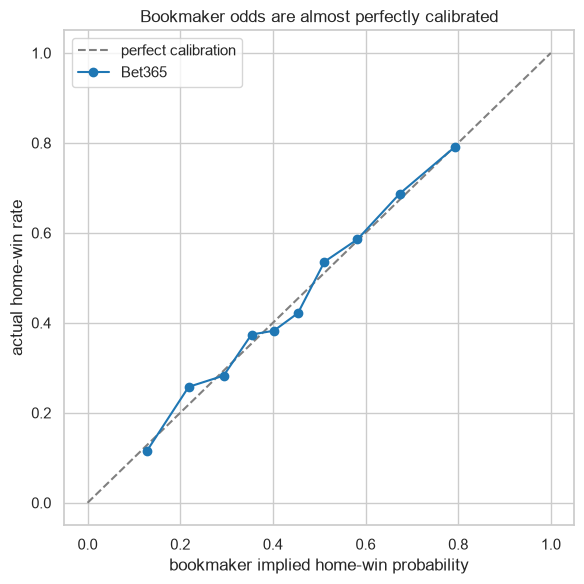

,implied,actual,n
bin,,,
"(0.0411, 0.178]",0.128,0.115,418
"(0.178, 0.257]",0.218,0.258,423
"(0.257, 0.327]",0.294,0.283,414
"(0.327, 0.379]",0.354,0.374,417
"(0.379, 0.425]",0.402,0.382,421
"(0.425, 0.481]",0.454,0.422,415
"(0.481, 0.547]",0.511,0.536,418
"(0.547, 0.623]",0.583,0.586,420
"(0.623, 0.729]",0.674,0.688,416


In [5]:
# Calibration: group matches into 10 bins by implied home-win probability,
# then compare the bin's average implied probability to the actual home-win rate.
calib = (
    matches.assign(bin=pd.qcut(matches["book_prob_home"], 10))
    .groupby("bin", observed=True)
    .agg(
        implied=("book_prob_home", "mean"),
        actual=("result", lambda r: (r == "H").mean()),
        n=("result", "size"),
    )
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
ax.plot(calib["implied"], calib["actual"], marker="o", color="#1f77b4", label="Bet365")
ax.set_xlabel("bookmaker implied home-win probability")
ax.set_ylabel("actual home-win rate")
ax.set_title("Bookmaker odds are almost perfectly calibrated")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "bookmaker_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

calib.round(3)

**Takeaway.** The bookmakers' favourite wins only **54.9%** of the time — that number should reset anyone's expectations. If an institution with money on the line, decades of data, and professional modelers tops out around 55%, a weekend project will not hit 70%. And their probabilities track the diagonal almost perfectly: when they say 60%, it happens ~60% of the time.

**Modeling consequence:** "beating the bookies" is not a realistic success criterion. Our honest goals: **clearly beat naive baselines** (always-home ≈ 44%) and **get as close to the bookmaker's log loss as possible**. We'll evaluate with log loss precisely because it scores the *probabilities*, not just the picks.

## 4. Why draws are so hard to predict

The favourite was **never** the draw — 0 matches out of 4,180. That's not a bookmaker quirk; it's structural. Intuition says evenly-matched teams should draw often. Let's measure it: how does the draw rate change as the matchup gets more lopsided (bigger gap between home and away win probabilities)?

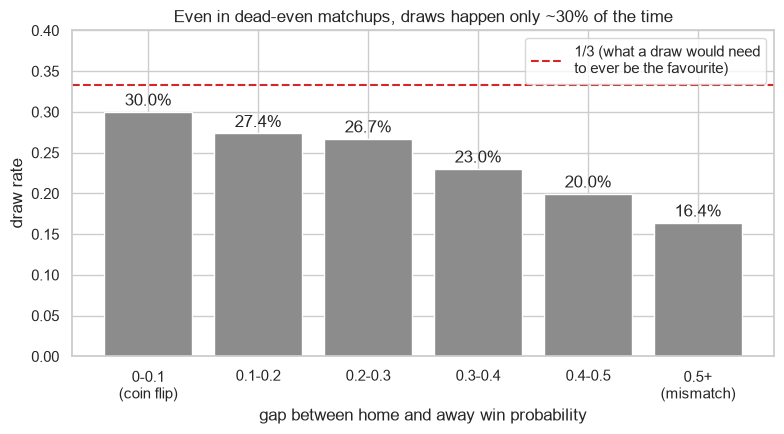

In [6]:
gap = (matches["book_prob_home"] - matches["book_prob_away"]).abs()
bins = pd.cut(gap, [0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0])
draw_rate = matches.groupby(bins, observed=True)["result"].apply(lambda r: (r == "D").mean())
labels = ["0-0.1\n(coin flip)", "0.1-0.2", "0.2-0.3", "0.3-0.4", "0.4-0.5", "0.5+\n(mismatch)"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, draw_rate.values, color="#8c8c8c")
ax.bar_label(bars, fmt=lambda v: f"{v:.1%}", padding=2)
ax.axhline(1 / 3, ls="--", color="#d62728", label="1/3 (what a draw would need\nto ever be the favourite)")
ax.set_ylim(0, 0.40)
ax.set_xlabel("gap between home and away win probability")
ax.set_ylabel("draw rate")
ax.set_title("Even in dead-even matchups, draws happen only ~30% of the time")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "draw_rate_by_evenness.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway.** Draw rate falls from 30% (dead-even matchups) to 16% (mismatches) — so evenness *does* raise draw probability, but it **never crosses 1/3**, the threshold where a draw would become the single most likely outcome. A model that predicts the most likely outcome will therefore essentially never say "draw", and its confusion matrix will show terrible draw recall. When we see that in notebook 03, we'll know it's a property of football, not a bug in our code.

## 5. What EDA tells us to build

| Finding | Modeling decision |
|---|---|
| Home advantage is large but drifts across seasons | Time-based train/test split; venue-aware form features |
| Scoring scale is stable across eras | Rolling goal averages usable without era adjustment |
| Bookmaker favourite wins only ~55%, perfectly calibrated | Evaluate with log loss vs bookmaker benchmark; ~55% is the ceiling, 44% (always-home) is the floor |
| Draws never exceed 1/3 probability | Expect near-zero draw recall; report per-class metrics, not just accuracy |

**Next:** [03_modeling_and_evaluation.ipynb](03_modeling_and_evaluation.ipynb) — build leakage-free form features, train baseline → logistic regression → gradient boosting, and find out how close we get to the bookies.